Loading CSV Files

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

colab = pd.read_csv("Benchmark Results/collab_svhn_benchmark_results.csv")
kaggle = pd.read_csv("Benchmark Results/kaggle_svhn_benchmark_results.csv")

colab["platform"] = "Colab"
kaggle["platform"] = "Kaggle"

df = pd.concat([colab, kaggle], ignore_index=True)
df["model"] = df["model"].str.upper()
df["dataset_label"] = df["dataset_fraction"].map({0.5: "50%", 1.0: "100%"})

plt.style.use("seaborn-v0_8-whitegrid")

def make_grouped_bar(data, title, xlabel, filename):
    ax = data.plot(
        kind="bar",
        figsize=(8, 5),
        color=["#3366CC", "#DC3912"],
        width=0.75,
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Average Training Time (seconds)")
    ax.legend(title="Platform")
    ax.tick_params(axis="x", rotation=0)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", padding=3, fontsize=9)

    plt.tight_layout()
    plt.savefig(filename, bbox_inches="tight")
    plt.show()

Graph 1: Platform Comparison

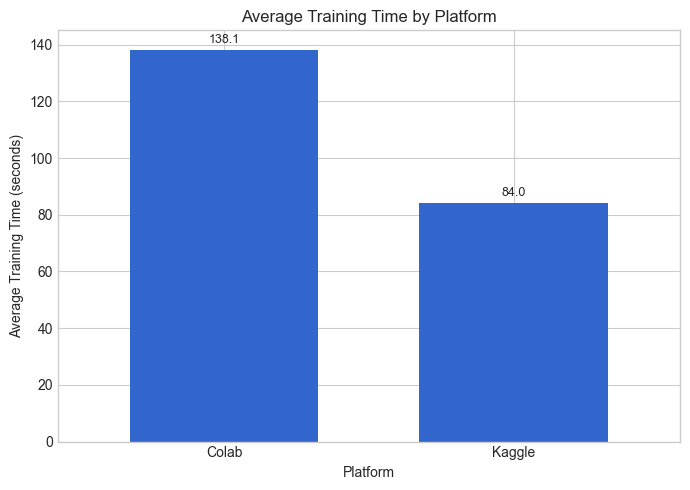

In [2]:
platform_avg = (
    df.groupby("platform")["total_train_time_s"]
    .mean()
    .reindex(["Colab", "Kaggle"])
    .to_frame(name="Average Training Time")
)

ax = platform_avg.plot(
    kind="bar",
    figsize=(7, 5),
    color=["#3366CC", "#DC3912"],
    width=0.65,
    legend=False,
)
ax.set_title("Average Training Time by Platform")
ax.set_xlabel("Platform")
ax.set_ylabel("Average Training Time (seconds)")
ax.tick_params(axis="x", rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3, fontsize=9)
plt.tight_layout()
plt.savefig("platform_comparison.png", bbox_inches="tight")
plt.show()

Graph 2: CPU vs GPU by Platform

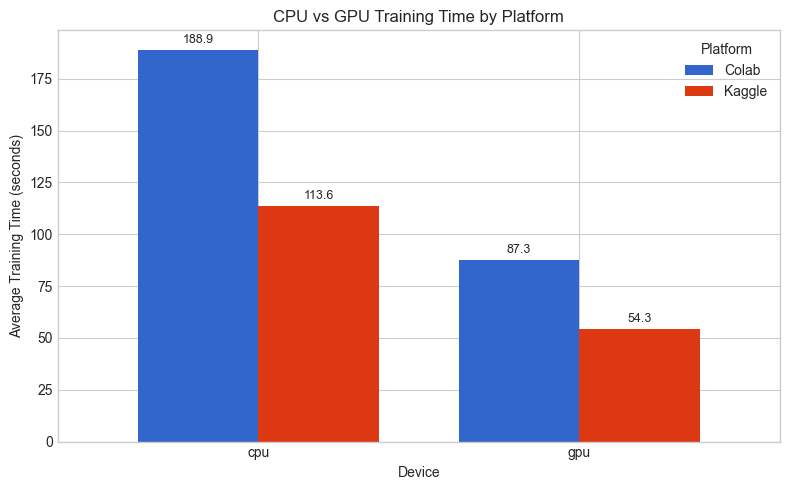

In [3]:
device_platform_avg = (
    df.groupby(["device_kind", "platform"])["total_train_time_s"]
    .mean()
    .unstack()
    .reindex(index=["cpu", "gpu"], columns=["Colab", "Kaggle"])
)

make_grouped_bar(
    device_platform_avg,
    "CPU vs GPU Training Time by Platform",
    "Device",
    "cpu_vs_gpu_comparison.png",
)


Graph 3: Model Comparison by Platform

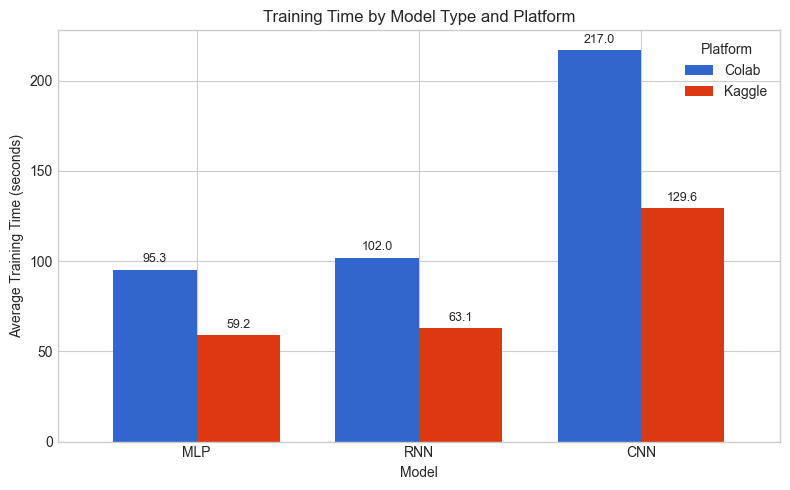

In [4]:
model_platform_avg = (
    df.groupby(["model", "platform"])["total_train_time_s"]
    .mean()
    .unstack()
    .reindex(index=["MLP", "RNN", "CNN"], columns=["Colab", "Kaggle"])
)

make_grouped_bar(
    model_platform_avg,
    "Training Time by Model Type and Platform",
    "Model",
    "model_comparison.png",
)


Graph 4: Dataset Size Effect by Platform

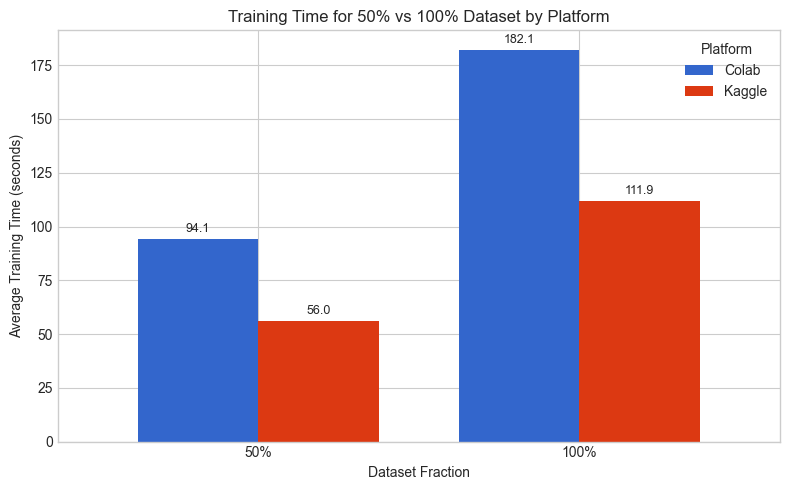

In [5]:
dataset_platform_avg = (
    df.groupby(["dataset_label", "platform"])["total_train_time_s"]
    .mean()
    .unstack()
    .reindex(index=["50%", "100%"], columns=["Colab", "Kaggle"])
)

make_grouped_bar(
    dataset_platform_avg,
    "Training Time for 50% vs 100% Dataset by Platform",
    "Dataset Fraction",
    "dataset_size_comparison.png",
)
